In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Configuración visual para gráficos estilo "publicación académica"
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.family": "serif"
})

print("Librerías importadas y entorno configurado.")

Librerías importadas y entorno configurado.


In [13]:
# Carga directa desde el archivo generado por el benchmark
csv_filename = "benchmark_granular_workflow.csv"

try:
    df = pd.read_csv(csv_filename)
    print(f"✅ Archivo '{csv_filename}' cargado exitosamente.")
    print(f"📊 Total de registros analizados: {len(df)}")
    
    # Separar los perfiles en Python y C++ para análisis específicos
    df_py = df[df['perfil'].isin(['seq', 'par', 'weights'])].copy()
    df_cpp = df[df['perfil'].str.startswith('cpp_')].copy()
    
    # Mostrar un resumen de los datos cargados
    display(df.head())
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{csv_filename}'.")
    print("Asegúrate de que el notebook esté en la misma carpeta que el CSV o ajusta la ruta.")

✅ Archivo 'benchmark_granular_workflow.csv' cargado exitosamente.
📊 Total de registros analizados: 600


,sample,n_nets,perfil,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
0,1,10,seq,0.852186,0.001338,0.314229,1.167753,169.507812,10.533203,361.578125,361.578125,38,68,1024
1,1,10,par,0.460802,0.043698,0.493096,0.997597,544.858398,50.521484,1044.702148,1044.702148,38,68,1024
2,1,10,weights,0.434926,0.035109,0.442846,0.912881,180.832031,38.020508,545.189453,545.189453,38,68,1024
3,1,10,cpp_seq,0.011063,0.000088,0.015481,0.026653,51.437500,1.375000,130.046875,182.859375,38,68,1024
4,1,10,cpp_par,0.006126,0.000047,0.014321,0.023855,55.812500,1.750000,128.343750,185.906250,38,68,1024


In [14]:
# Verificamos que para cada 'sample', el número de atractores, pares y campos sea idéntico en todos los perfiles
integrity_check = df.groupby('sample')[['n_attractors', 'n_pairs', 'n_fields']].nunique()

is_consistent = (integrity_check == 1).all().all()

if is_consistent:
    print("✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.")
else:
    print("❌ ADVERTENCIA: Hay discrepancias en los resultados topológicos entre los perfiles.")
    display(integrity_check[integrity_check > 1].dropna())

✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.


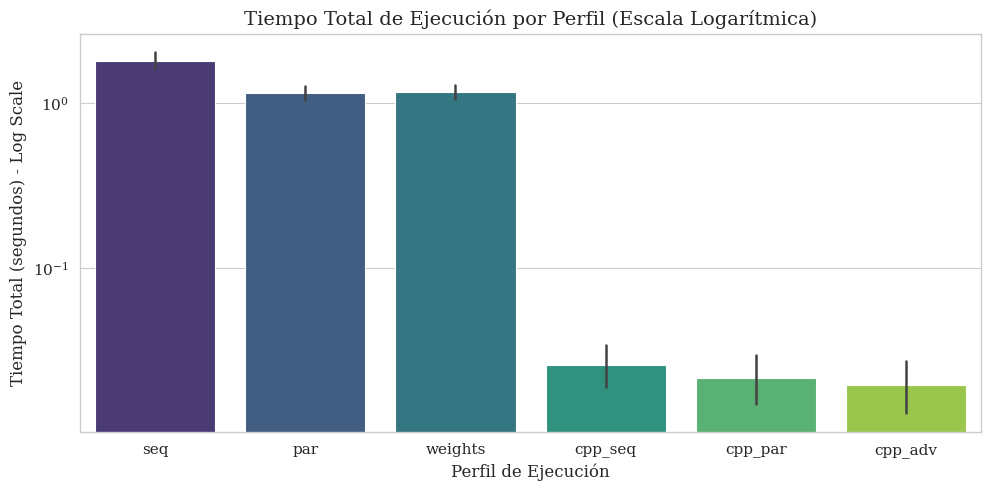

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='perfil', y='total_t', hue='perfil', palette='viridis', legend=False, ax=ax)
ax.set_title("Tiempo Total de Ejecución por Perfil (Escala Logarítmica)")
ax.set_ylabel("Tiempo Total (segundos) - Log Scale")
ax.set_xlabel("Perfil de Ejecución")
ax.set_yscale("log") # Usamos escala logarítmica porque la diferencia es inmensa

plt.tight_layout()
plt.show()



In [16]:
# Calcular el Speedup (Secuencial Python vs Secuencial C++)
t_py_seq = df.loc[df['perfil'] == 'seq', 'total_t'].values[0]
t_cpp_seq = df.loc[df['perfil'] == 'cpp_seq', 'total_t'].values[0]
speedup = t_py_seq / t_cpp_seq

print(f"⏱️ Tiempo Python Secuencial: {t_py_seq:.4f} s")
print(f"⏱️ Tiempo C++ Secuencial:    {t_cpp_seq:.4f} s")
print(f"🚀 SPEEDUP GENERAL: C++ es {speedup:.2f} veces más rápido que Python para esta muestra.")

⏱️ Tiempo Python Secuencial: 1.1678 s
⏱️ Tiempo C++ Secuencial:    0.0267 s
🚀 SPEEDUP GENERAL: C++ es 43.81 veces más rápido que Python para esta muestra.


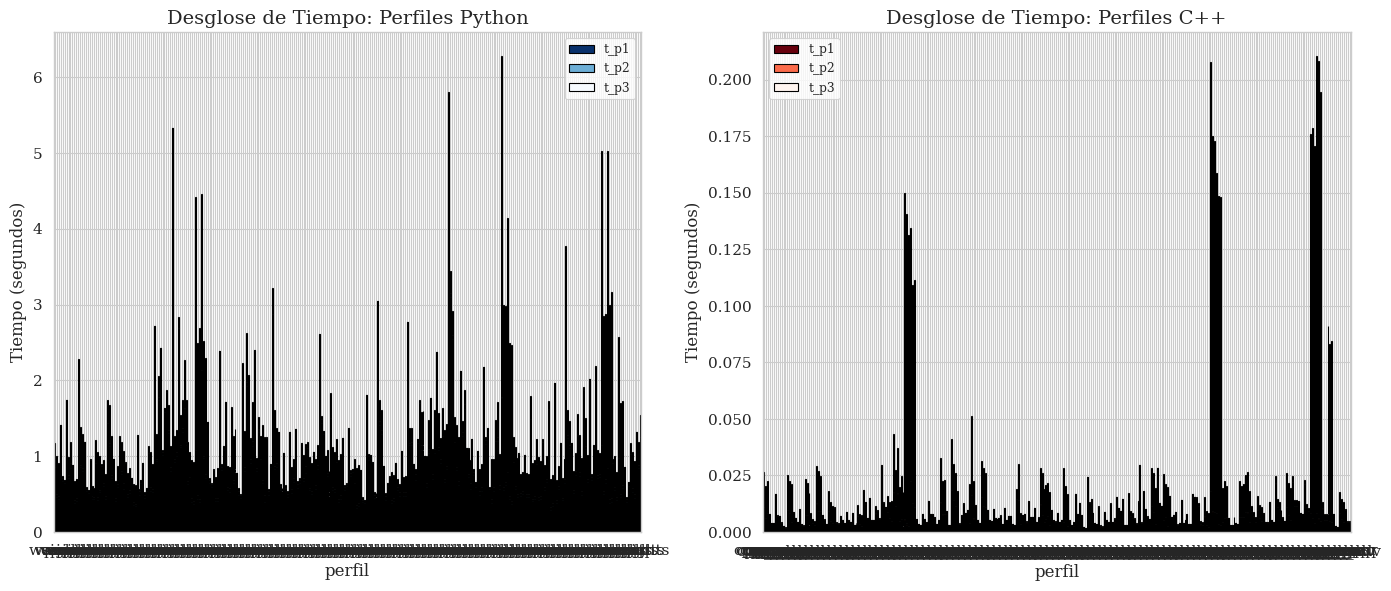

In [17]:
# Preparar datos para barras apiladas
perfiles = df['perfil'].values
t_p1 = df['t_p1'].values
t_p2 = df['t_p2'].values
t_p3 = df['t_p3'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Python
df_py.set_index('perfil')[['t_p1', 't_p2', 't_p3']].plot(
    kind='bar', stacked=True, ax=ax1, colormap='Blues_r', edgecolor='black'
)
ax1.set_title("Desglose de Tiempo: Perfiles Python")
ax1.set_ylabel("Tiempo (segundos)")
ax1.tick_params(axis='x', rotation=0)

# Gráfico 2: C++
df_cpp.set_index('perfil')[['t_p1', 't_p2', 't_p3']].plot(
    kind='bar', stacked=True, ax=ax2, colormap='Reds_r', edgecolor='black'
)
ax2.set_title("Desglose de Tiempo: Perfiles C++")
ax2.set_ylabel("Tiempo (segundos)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

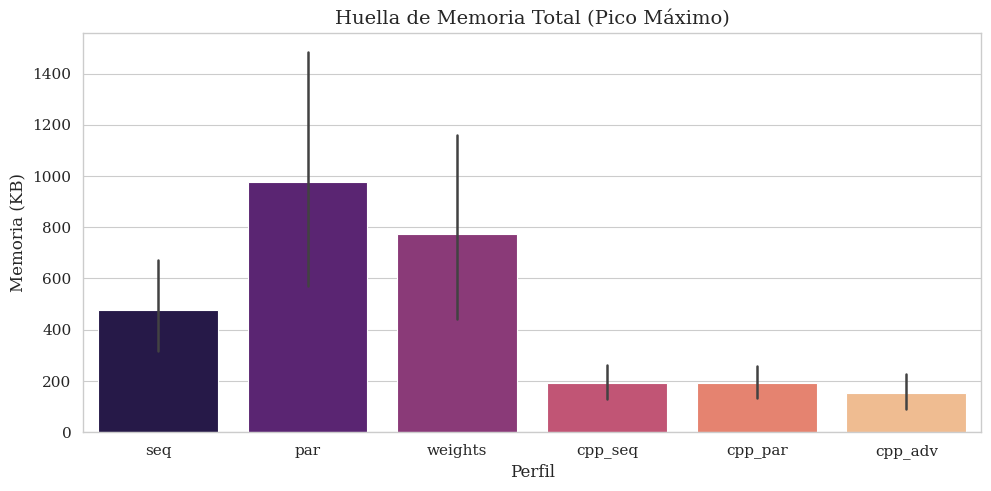

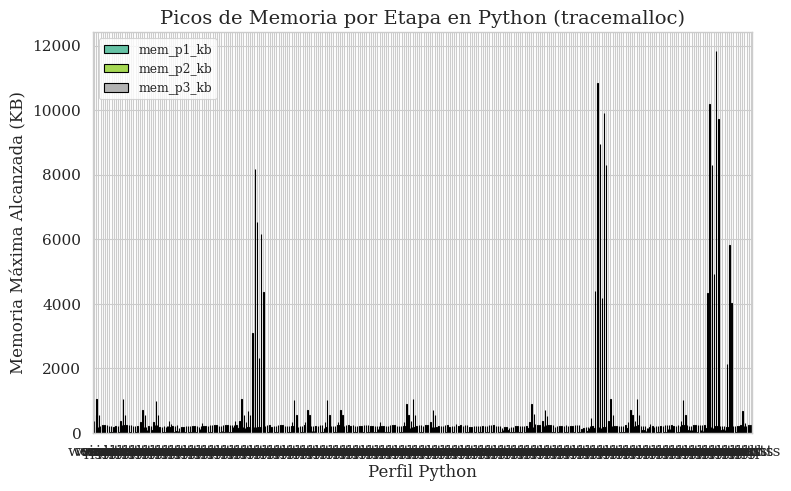

🚨 Pico máximo de memoria en Python (para n_nets=10): 11820.09 KB
Nota: Observa qué etapa (P1, P2 o P3) es la responsable de alocar más memoria. Ese es el cuello de botella que causa el OOM en el clúster.


In [18]:
# 1. Comparativa de Memoria Máxima (Total) entre todos los perfiles
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='perfil', y='mem_total_kb', hue='perfil', palette='magma', legend=False, ax=ax)
ax.set_title("Huella de Memoria Total (Pico Máximo)")
ax.set_ylabel("Memoria (KB)")
ax.set_xlabel("Perfil")
plt.tight_layout()
plt.show()

# 2. Desglose de Memoria Interna solo para Python (tracemalloc)
df_py_mem = df_py[['perfil', 'mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].set_index('perfil')

fig, ax = plt.subplots(figsize=(8, 5))
df_py_mem.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title("Picos de Memoria por Etapa en Python (tracemalloc)")
ax.set_ylabel("Memoria Máxima Alcanzada (KB)")
ax.set_xlabel("Perfil Python")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis textual de memoria en Python
max_mem_py = df_py['mem_total_kb'].max()
print(f"🚨 Pico máximo de memoria en Python (para n_nets=10): {max_mem_py:.2f} KB")
print("Nota: Observa qué etapa (P1, P2 o P3) es la responsable de alocar más memoria. Ese es el cuello de botella que causa el OOM en el clúster.")

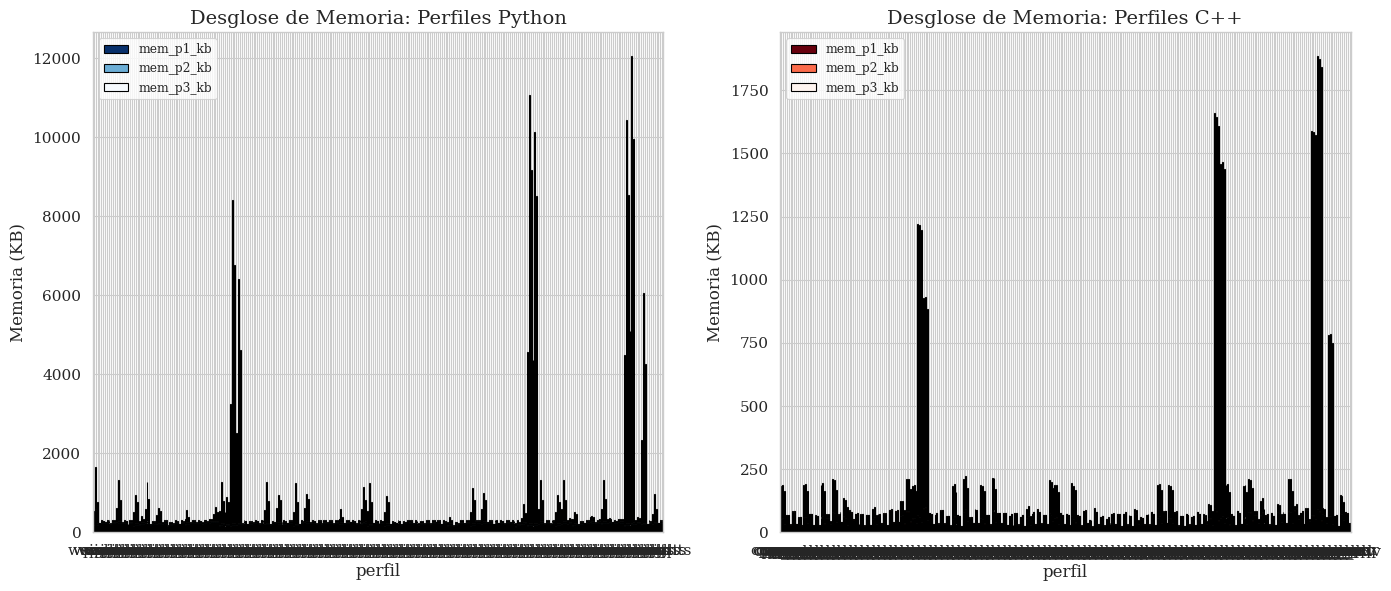

In [19]:
# Celda 6 (Actualizada): Análisis Profundo de Memoria por Etapas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Python
df_py_mem = df_py[['perfil', 'mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].set_index('perfil')
df_py_mem.plot(kind='bar', stacked=True, ax=ax1, colormap='Blues_r', edgecolor='black')
ax1.set_title("Desglose de Memoria: Perfiles Python")
ax1.set_ylabel("Memoria (KB)")
ax1.tick_params(axis='x', rotation=0)

# Gráfico 2: C++ (¡Ahora con datos reales gracias a Jules!)
df_cpp_mem = df_cpp[['perfil', 'mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].set_index('perfil')
df_cpp_mem.plot(kind='bar', stacked=True, ax=ax2, colormap='Reds_r', edgecolor='black')
ax2.set_title("Desglose de Memoria: Perfiles C++")
ax2.set_ylabel("Memoria (KB)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

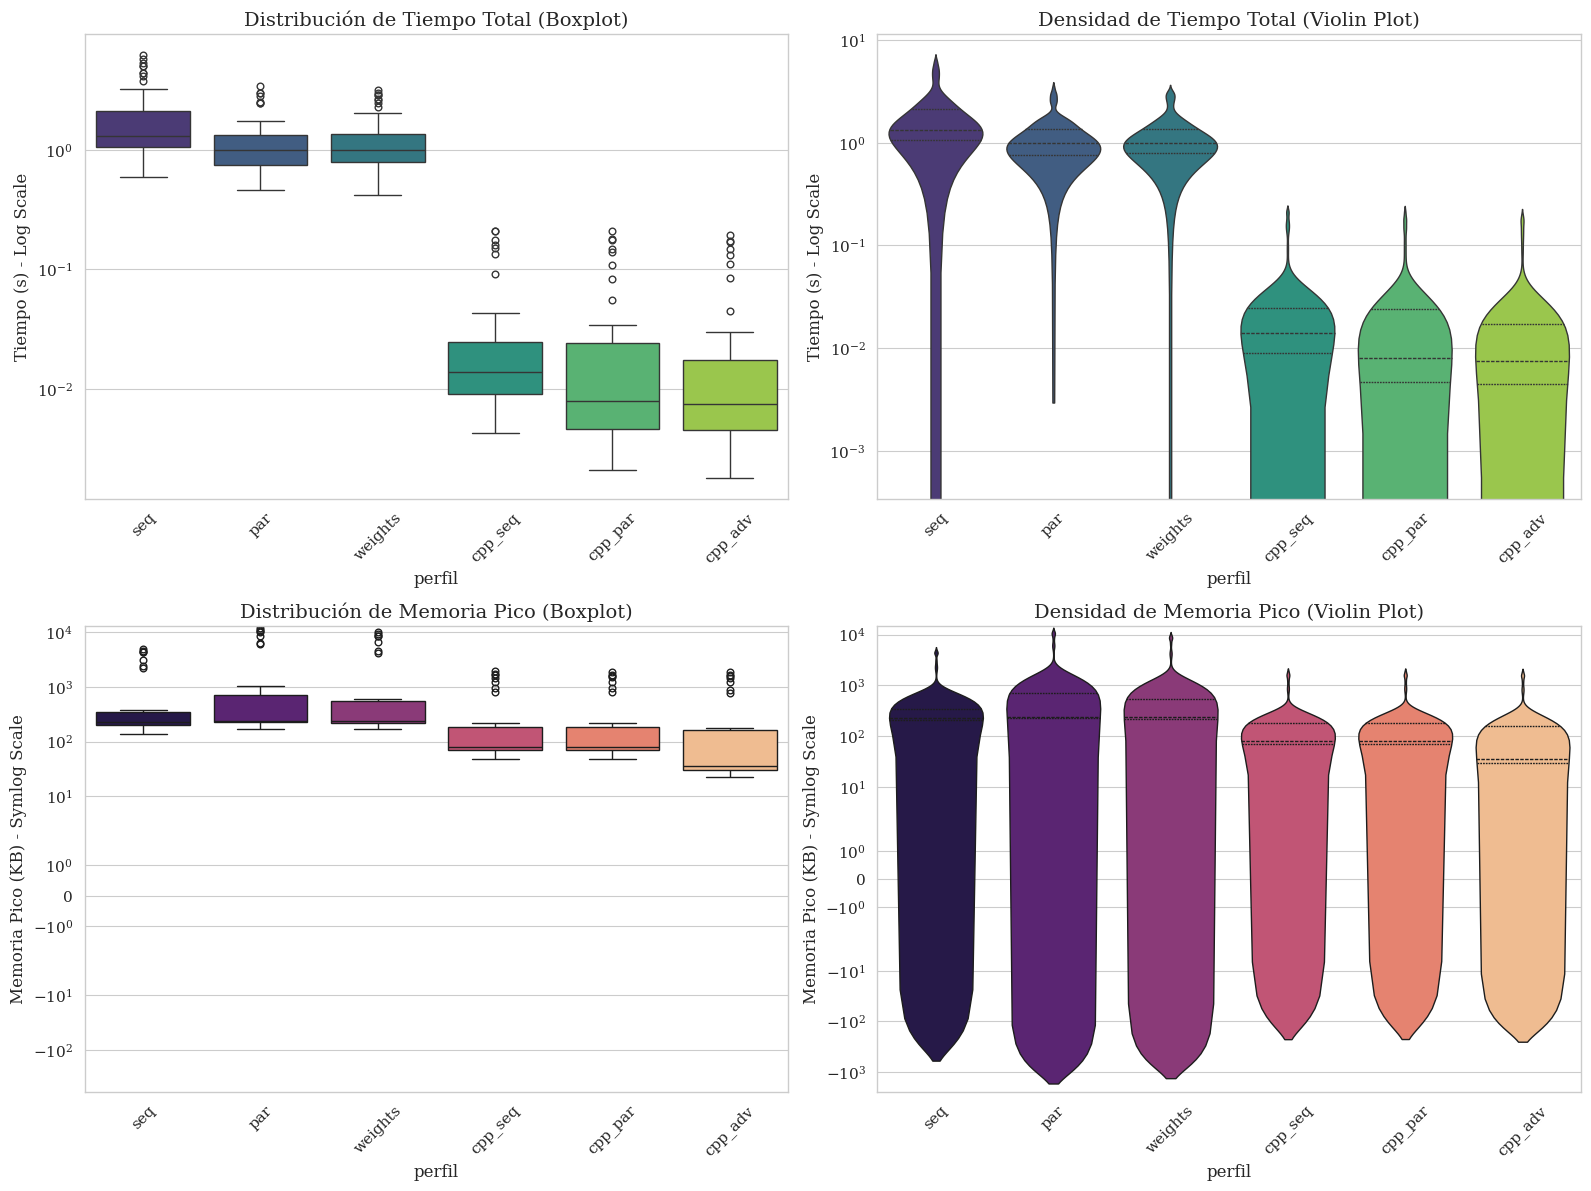

In [20]:
# Celda 7: Distribución de Tiempos y Memoria (Boxplots y Violines)

# Crear una figura con 2 filas (Tiempo, Memoria) y 2 columnas (Boxplot, Violin)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- FILA 1: ANÁLISIS DE TIEMPO (total_t) ---
# Boxplot de Tiempo
sns.boxplot(data=df, x='perfil', y='total_t', hue='perfil', ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('Distribución de Tiempo Total (Boxplot)')
axes[0, 0].set_ylabel('Tiempo (s) - Log Scale')
axes[0, 0].set_yscale('log')
axes[0, 0].tick_params(axis='x', rotation=45)

# Violin Plot de Tiempo
sns.violinplot(data=df, x='perfil', y='total_t', hue='perfil', ax=axes[0, 1], palette='viridis', legend=False, inner='quartile')
axes[0, 1].set_title('Densidad de Tiempo Total (Violin Plot)')
axes[0, 1].set_ylabel('Tiempo (s) - Log Scale')
axes[0, 1].set_yscale('log')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- FILA 2: ANÁLISIS DE MEMORIA (mem_total_kb) ---
# Usamos 'symlog' (symmetrical log) en caso de que alguna medición de memoria registre 0.0 KB
# Boxplot de Memoria
sns.boxplot(data=df, x='perfil', y='mem_total_kb', hue='perfil', ax=axes[1, 0], palette='magma', legend=False)
axes[1, 0].set_title('Distribución de Memoria Pico (Boxplot)')
axes[1, 0].set_ylabel('Memoria Pico (KB) - Symlog Scale')
axes[1, 0].set_yscale('symlog')
axes[1, 0].tick_params(axis='x', rotation=45)

# Violin Plot de Memoria
sns.violinplot(data=df, x='perfil', y='mem_total_kb', hue='perfil', ax=axes[1, 1], palette='magma', legend=False, inner='quartile')
axes[1, 1].set_title('Densidad de Memoria Pico (Violin Plot)')
axes[1, 1].set_ylabel('Memoria Pico (KB) - Symlog Scale')
axes[1, 1].set_yscale('symlog')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Celda 8: Análisis Estadístico Descriptivo

print("=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===")
# Agrupamos por perfil y calculamos métricas clave
time_stats = df.groupby('perfil')['total_t'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos de más lento a más rápido
time_stats = time_stats.sort_values(by='Media', ascending=False)
display(time_stats.style.format("{:.6f}", na_rep="-").background_gradient(cmap='Blues'))

print("\n=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===")
mem_stats = df.groupby('perfil')['mem_total_kb'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos del que consume más memoria al que menos
mem_stats = mem_stats.sort_values(by='Media', ascending=False)
display(mem_stats.style.format("{:.2f}", na_rep="-").background_gradient(cmap='Reds'))

=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
seq,100.000000,1.798892,1.161798,1.320858,0.598864,6.278377
weights,100.000000,1.168818,0.581678,1.001972,0.421943,3.164523
par,100.000000,1.141796,0.578859,0.995572,0.463842,3.439360
cpp_seq,100.000000,0.025845,0.039590,0.013948,0.004234,0.210579
cpp_par,100.000000,0.021467,0.038242,0.007967,0.002108,0.209464
cpp_adv,100.000000,0.019540,0.036665,0.007429,0.001794,0.194893



=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
par,100.00,976.74,2298.83,232.58,167.32,11820.09
weights,100.00,773.72,1853.37,232.65,169.16,9715.00
seq,100.00,478.00,911.25,223.96,135.59,4917.67
cpp_seq,100.00,190.24,340.95,81.12,48.42,1886.30
cpp_par,100.00,190.04,339.78,80.15,48.91,1875.02
cpp_adv,100.00,153.21,342.36,35.25,22.50,1840.70


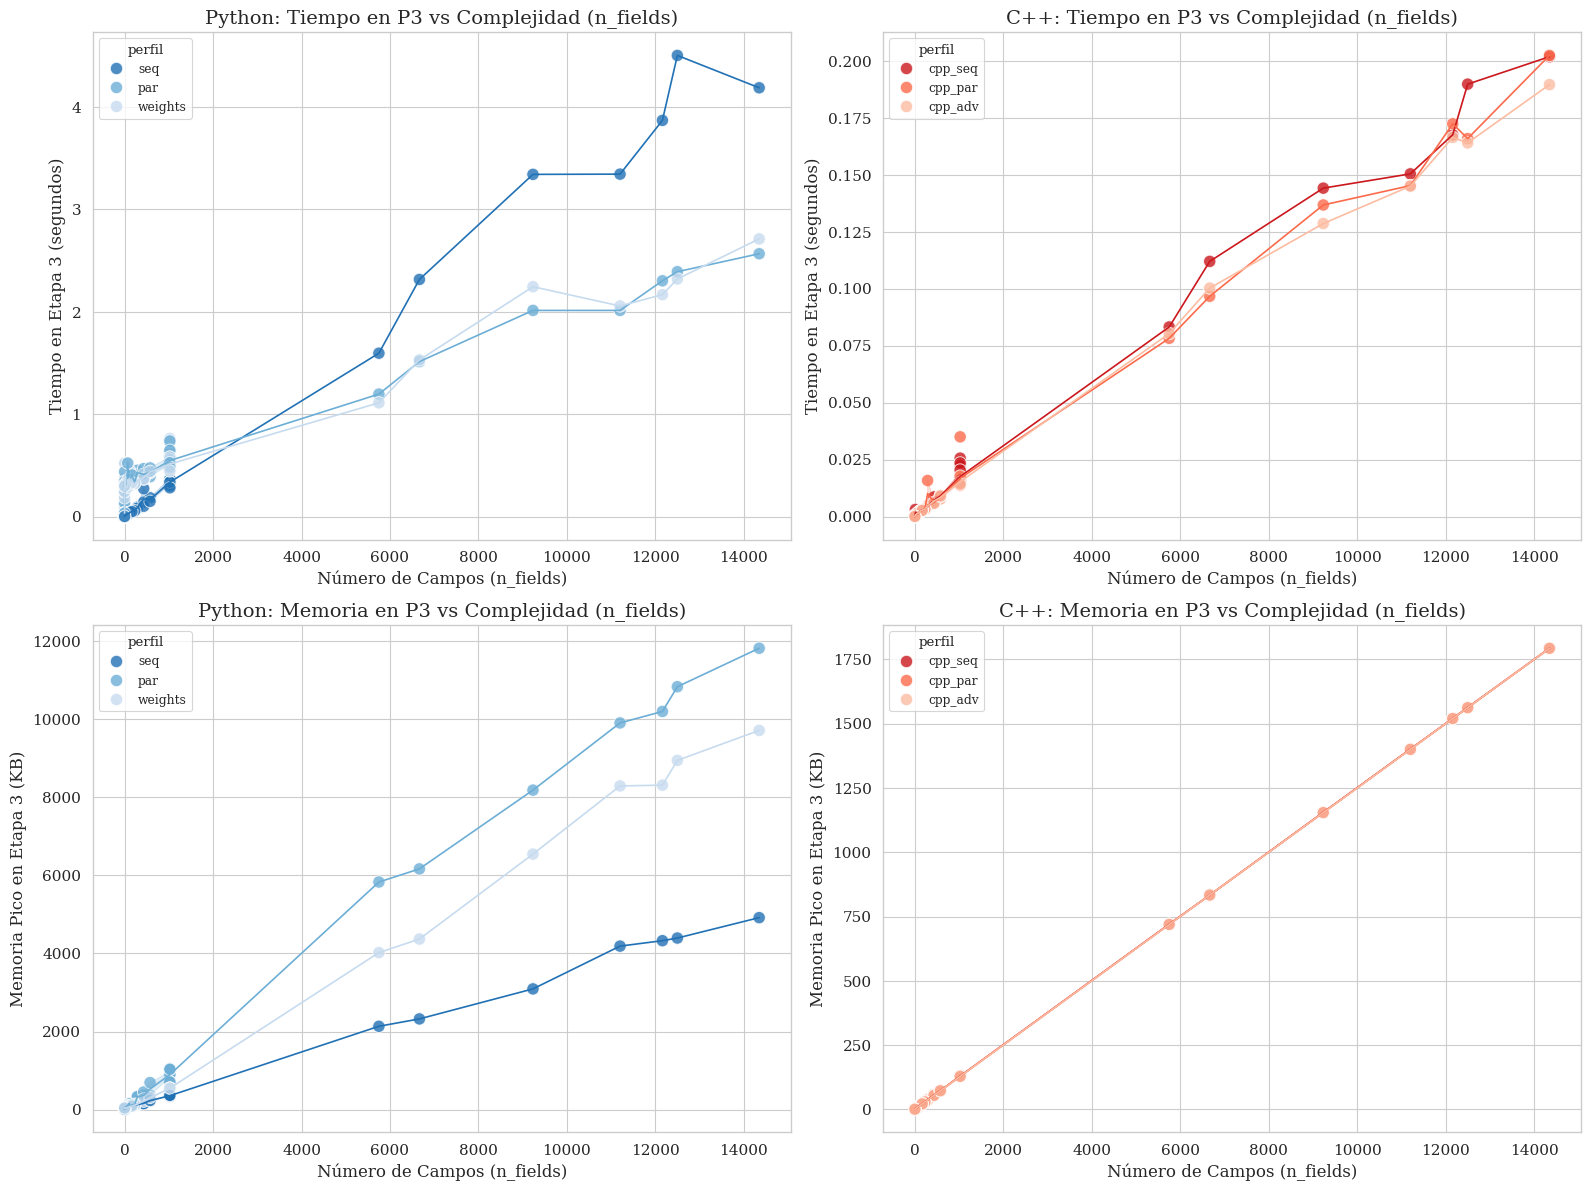

=== 📈 CORRELACIÓN (PEARSON) CON n_fields EN LA ETAPA 3 ===
🐍 PYTHON:
  • Correlación n_fields vs Tiempo P3:  0.9344
  • Correlación n_fields vs Memoria P3: 0.9407

⚙️ C++:
  • Correlación n_fields vs Tiempo P3:  0.9969
  • Correlación n_fields vs Memoria P3: 1.0000


In [22]:
# Celda 9 (Actualizada): Relación de Complejidad (n_fields) vs Tiempo y Memoria en la Etapa 3 (P3)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- FILA 1: TIEMPO EN P3 (t_p3) vs n_fields ---

# Gráfico 1,0: Python (Tiempo P3)
sns.scatterplot(data=df_py, x='n_fields', y='t_p3', hue='perfil', ax=axes[0, 0], palette='Blues_r', s=80, alpha=0.8)
sns.lineplot(data=df_py, x='n_fields', y='t_p3', hue='perfil', ax=axes[0, 0], palette='Blues_r', legend=False)
axes[0, 0].set_title('Python: Tiempo en P3 vs Complejidad (n_fields)')
axes[0, 0].set_ylabel('Tiempo en Etapa 3 (segundos)')
axes[0, 0].set_xlabel('Número de Campos (n_fields)')

# Gráfico 1,1: C++ (Tiempo P3)
sns.scatterplot(data=df_cpp, x='n_fields', y='t_p3', hue='perfil', ax=axes[0, 1], palette='Reds_r', s=80, alpha=0.8)
sns.lineplot(data=df_cpp, x='n_fields', y='t_p3', hue='perfil', ax=axes[0, 1], palette='Reds_r', legend=False)
axes[0, 1].set_title('C++: Tiempo en P3 vs Complejidad (n_fields)')
axes[0, 1].set_ylabel('Tiempo en Etapa 3 (segundos)')
axes[0, 1].set_xlabel('Número de Campos (n_fields)')

# --- FILA 2: MEMORIA EN P3 vs n_fields ---

# Gráfico 2,0: Python (Memoria P3)
sns.scatterplot(data=df_py, x='n_fields', y='mem_p3_kb', hue='perfil', ax=axes[1, 0], palette='Blues_r', s=80, alpha=0.8)
sns.lineplot(data=df_py, x='n_fields', y='mem_p3_kb', hue='perfil', ax=axes[1, 0], palette='Blues_r', legend=False)
axes[1, 0].set_title('Python: Memoria en P3 vs Complejidad (n_fields)')
axes[1, 0].set_ylabel('Memoria Pico en Etapa 3 (KB)')
axes[1, 0].set_xlabel('Número de Campos (n_fields)')

# Gráfico 2,1: C++ (Memoria P3 Específica)
sns.scatterplot(data=df_cpp, x='n_fields', y='mem_p3_kb', hue='perfil', ax=axes[1, 1], palette='Reds_r', s=80, alpha=0.8)
sns.lineplot(data=df_cpp, x='n_fields', y='mem_p3_kb', hue='perfil', ax=axes[1, 1], palette='Reds_r', legend=False)
axes[1, 1].set_title('C++: Memoria en P3 vs Complejidad (n_fields)')
axes[1, 1].set_ylabel('Memoria Pico en Etapa 3 (KB)')
axes[1, 1].set_xlabel('Número de Campos (n_fields)')

plt.tight_layout()
plt.show()

# --- ANÁLISIS DE CORRELACIÓN ---
print("=== 📈 CORRELACIÓN (PEARSON) CON n_fields EN LA ETAPA 3 ===")

print("🐍 PYTHON:")
if df_py['n_fields'].nunique() > 1:
    corr_py_t = df_py['n_fields'].corr(df_py['t_p3'])
    corr_py_m = df_py['n_fields'].corr(df_py['mem_p3_kb'])
    print(f"  • Correlación n_fields vs Tiempo P3:  {corr_py_t:.4f}")
    print(f"  • Correlación n_fields vs Memoria P3: {corr_py_m:.4f}")
else:
    print("  • Ejecuta el benchmark con múltiples topologías para calcular la correlación.")

print("\n⚙️ C++:")
if df_cpp['n_fields'].nunique() > 1:
    corr_cpp_t = df_cpp['n_fields'].corr(df_cpp['t_p3'])
    corr_cpp_m = df_cpp['n_fields'].corr(df_cpp['mem_p3_kb'])
    print(f"  • Correlación n_fields vs Tiempo P3:  {corr_cpp_t:.4f}")
    print(f"  • Correlación n_fields vs Memoria P3: {corr_cpp_m:.4f}")
else:
    print("  • Ejecuta el benchmark con múltiples topologías para calcular la correlación.")

In [23]:
df.describe()

,sample,n_nets,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
count,600.000000,600.0,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000
mean,50.500000,10.0,0.489170,0.015363,0.191307,0.696060,135.247656,14.836628,368.175439,460.327274,27.99000,35.770000,953.770000
std,28.890155,0.0,0.681386,0.021792,0.491550,0.914332,82.921740,16.897416,1337.236700,1318.003198,9.25379,29.621943,2701.090979
min,1.000000,10.0,0.001700,0.000038,0.000017,0.001794,21.187500,0.859375,0.000000,22.500000,19.00000,1.000000,0.000000
25%,25.750000,10.0,0.006481,0.000053,0.000127,0.010042,61.707031,1.308594,0.703125,74.660156,19.00000,11.750000,0.000000
50%,50.500000,10.0,0.161189,0.001188,0.009707,0.316261,116.263672,4.605957,32.311523,200.939941,29.00000,28.000000,1.000000
75%,75.250000,10.0,0.799849,0.038407,0.261194,1.110397,220.144531,37.346680,128.562500,234.681152,38.00000,68.000000,1024.000000
max,100.000000,10.0,5.794797,0.096116,4.503847,6.278377,544.858398,50.521484,11820.094727,11820.094727,48.00000,109.000000,14345.000000
